# Pronóstico de Series de Tiempo con DARTS
## Caso de Estudio: Producción Mensual de Café

---

> **DARTS** (Deep AR Time Series) es un framework unificado de Python que permite construir, entrenar y evaluar decenas de modelos de series de tiempo con una API consistente.

### ¿Qué aprenderás en este cuaderno?

1. Explorar y descomponer una serie de tiempo real
2. Aplicar pruebas de estacionariedad (ADF)
3. Entrenar **7 modelos** de distintas familias
4. Evaluar y comparar con métricas estándar (MAE, RMSE, MAPE, sMAPE)

### Modelos cubiertos

| # | Modelo | Familia | Requiere entrenamiento |
|---|--------|---------|------------------------|
| 1 | **Naive Seasonal** | Baseline | No |
| 2 | **Holt-Winters (ETS)** | Estadístico | Sí |
| 3 | **AutoARIMA / SARIMA** | Estadístico | Sí |
| 4 | **Prophet** | Aditivo descomponible | Sí |
| 5 | **LightGBM** | Machine Learning | Sí |
| 6 | **Random Forest** | Machine Learning | Sí |
| 7 | **Chronos-2** | Foundation Model (LLM) | No (zero-shot) |

### Métricas de evaluación
- **MAE** – Error Absoluto Medio (misma unidad que la serie)
- **RMSE** – Raíz del Error Cuadrático Medio (penaliza errores grandes)
- **MAPE** – Error Porcentual Absoluto Medio (interpretable %)
- **sMAPE** – MAPE Simétrico (más robusto cuando los valores son pequeños)

---
**Datos:** Producción mensual de café · 2000-01 a 2026-01 · 313 observaciones

---
## 1. Instalación de Dependencias

Ejecuta esta celda **una sola vez** para instalar todas las librerías necesarias.
Si ya las tienes instaladas, puedes saltarla.

In [1]:
# Descomenta y ejecuta solo si necesitas instalar
%pip install -q "darts[all]" lightgbm prophet pmdarima statsforecast
%pip install -q "chronos-forecasting>=2.0"


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch

# Estadística y diagnóstico
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── DARTS ──────────────────────────────────────────────────────────────────
from darts import TimeSeries

# Modelos estadísticos / clásicos
from darts.models import (
    NaiveSeasonal,
    ExponentialSmoothing,
    AutoARIMA,
    Prophet,
)

# Modelos de Machine Learning
from darts.models import (
    LightGBMModel,
    RandomForest,
)

# Métricas
from darts.metrics import mae, rmse, mape, smape
from darts.utils.utils import ModelMode, SeasonalityMode

# ── Estilo visual ───────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
})

HORIZONTE = 24   # meses a pronosticar (2 años)
SEMILLA    = 42  # reproducibilidad

print("✓ Librerías cargadas correctamente.")
print(f"  DARTS disponible · Horizonte de pronóstico: {HORIZONTE} meses")

✓ Librerías cargadas correctamente.
  DARTS disponible · Horizonte de pronóstico: 24 meses


---
## 3. Carga y Exploración de Datos

Trabajamos con la serie de **producción mensual de café** (miles de sacos de 60 kg).

Fuente: repositorio público en GitHub.

In [3]:
URL = "https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/Data/cafe.xlsx"

df = pd.read_excel(URL)
df.columns = ["Fecha", "Produccion"]     # nombres limpios sin tilde
df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df.set_index("Fecha").asfreq("MS")  # frecuencia mensual (Month Start)
df = df.sort_index()

print(f"Periodo : {df.index.min().date()}  →  {df.index.max().date()}")
print(f"Registros: {len(df)} observaciones mensuales")
print(f"\nValores faltantes: {df.isnull().sum().values[0]}")
df.head()

Periodo : 2000-01-01  →  2026-01-01
Registros: 313 observaciones mensuales

Valores faltantes: 0


,Produccion
Fecha,
2000-01-01,658.0
2000-02-01,740.0
2000-03-01,592.0
2000-04-01,1055.0
2000-05-01,1114.0


count     313.000000
mean      980.703350
std       263.829037
min       345.000000
25%       788.000000
50%       981.000000
75%      1151.000000
max      1798.230552


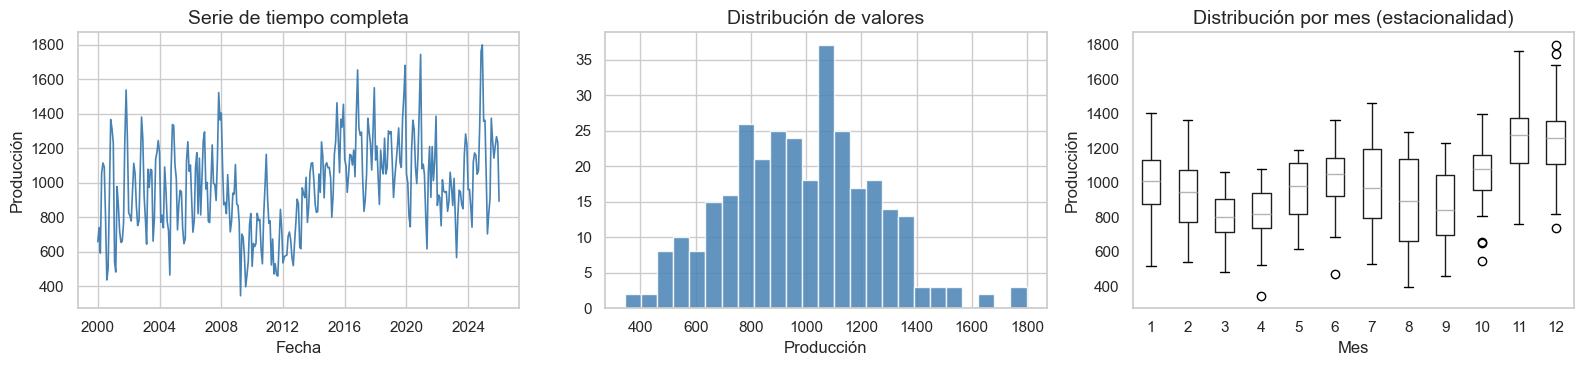

In [4]:
# ── Estadísticas descriptivas ───────────────────────────────────────────────
stats = df["Produccion"].describe().rename("Producción de café")
print(stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Serie completa
axes[0].plot(df.index, df["Produccion"], color="steelblue", linewidth=1.2)
axes[0].set_title("Serie de tiempo completa")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Producción")

# Distribución
axes[1].hist(df["Produccion"], bins=25, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].set_title("Distribución de valores")
axes[1].set_xlabel("Producción")

# Boxplot por mes (estacionalidad)
df_temp = df.copy()
df_temp["Mes"] = df_temp.index.month
df_temp.boxplot(column="Produccion", by="Mes", ax=axes[2], grid=False)
axes[2].set_title("Distribución por mes (estacionalidad)")
axes[2].set_xlabel("Mes")
axes[2].set_ylabel("Producción")
plt.suptitle("")   # elimina el título automático de boxplot

plt.tight_layout()
plt.show()

---
## 4. Análisis de la Serie: Descomposición y Diagnóstico

Una serie de tiempo puede descomponerse en tres componentes:

$$Y_t = T_t + S_t + R_t \quad \text{(aditiva)} \qquad\text{o}\qquad Y_t = T_t \times S_t \times R_t \quad \text{(multiplicativa)}$$

- **Tendencia** $T_t$: dirección de largo plazo
- **Estacionalidad** $S_t$: patrón repetitivo (aquí, anual de 12 meses)
- **Residuo** $R_t$: variación aleatoria no explicada

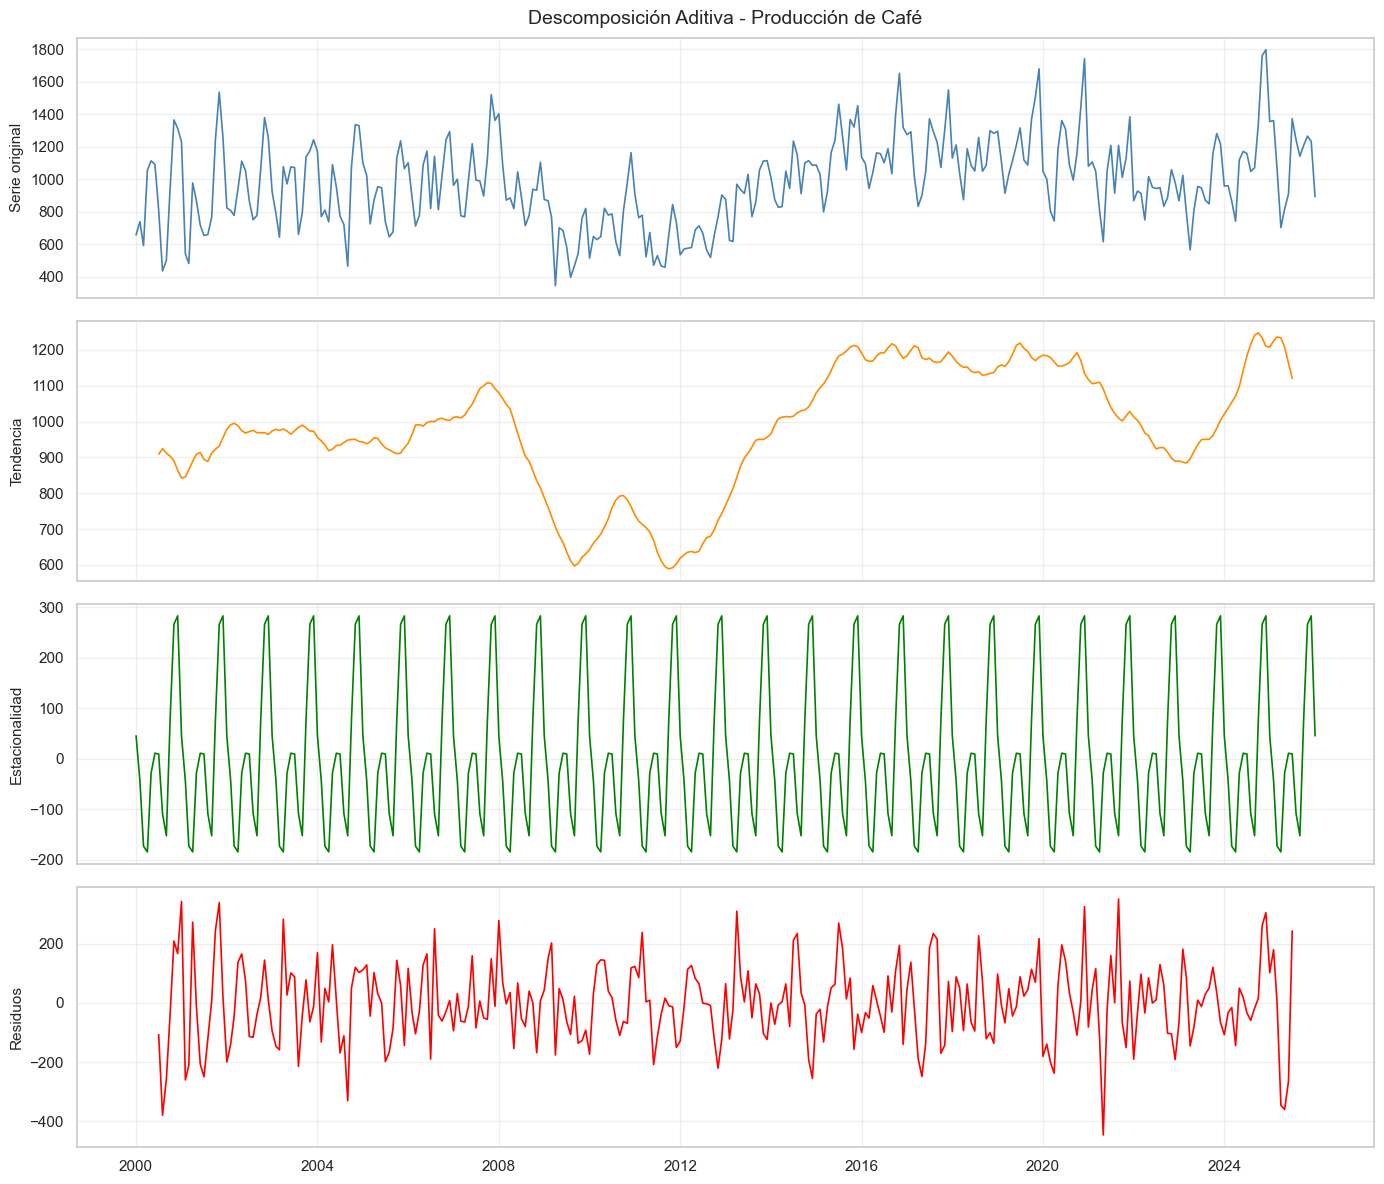

In [5]:
descomp = seasonal_decompose(df["Produccion"], model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
componentes = [
    (descomp.observed,   "Serie original",  "steelblue"),
    (descomp.trend,      "Tendencia",        "darkorange"),
    (descomp.seasonal,   "Estacionalidad",   "green"),
    (descomp.resid,      "Residuos",         "red"),
]

for ax, (serie, titulo, color) in zip(axes, componentes):
    ax.plot(serie, color=color, linewidth=1.2)
    ax.set_ylabel(titulo, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Descomposición Aditiva - Producción de Café", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

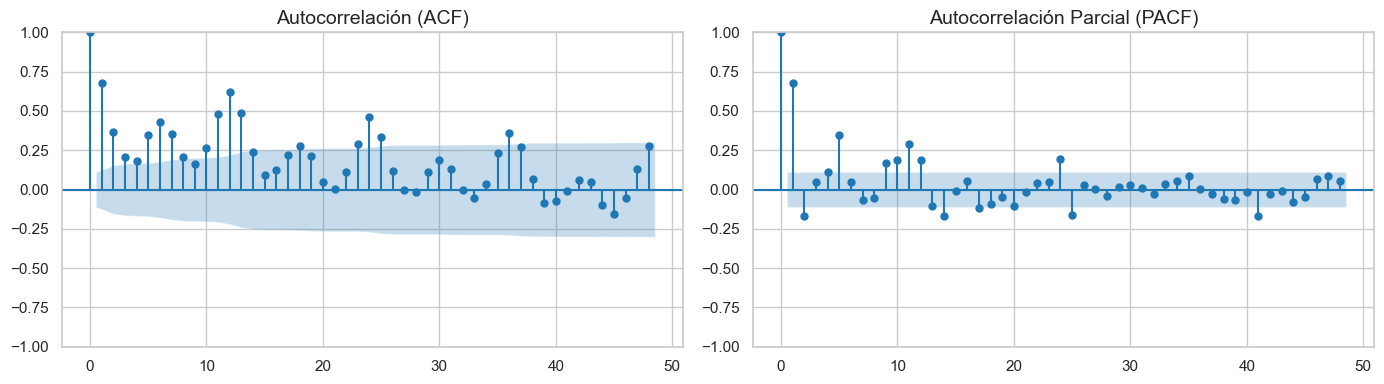


Interpretación:
  • ACF con picos significativos en lags 12, 24, 36 → clara estacionalidad anual
  • PACF decae rápido → componente AR de bajo orden
  → Modelo sugerido: SARIMA(p,d,q)(P,D,Q)[12]



In [6]:
# ── ACF y PACF: identificamos autocorrelaciones ────────────────────────────
# ACF → indica orden del MA(q)  |  PACF → indica orden del AR(p)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["Produccion"],  lags=48, ax=axes[0], title="Autocorrelación (ACF)")
plot_pacf(df["Produccion"], lags=48, ax=axes[1], title="Autocorrelación Parcial (PACF)")
plt.tight_layout()
plt.show()

print("""
Interpretación:
  • ACF con picos significativos en lags 12, 24, 36 → clara estacionalidad anual
  • PACF decae rápido → componente AR de bajo orden
  → Modelo sugerido: SARIMA(p,d,q)(P,D,Q)[12]
""")

In [7]:
# ── Prueba ADF: ¿es estacionaria la serie? ─────────────────────────────────
# H₀: la serie tiene raíz unitaria (NO es estacionaria)
# Rechazamos H₀ si p-value < 0.05

def prueba_adf(serie, nombre="Serie"):
    resultado = adfuller(serie.dropna(), autolag='AIC')
    p = resultado[1]
    print(f"\n{'─'*50}")
    print(f" Prueba ADF – {nombre}")
    print(f"{'─'*50}")
    print(f" Estadístico ADF : {resultado[0]:.4f}")
    print(f" p-value         : {p:.4f}")
    print(f" Lags usados     : {resultado[2]}")
    for clave, val in resultado[4].items():
        print(f"  Valor crítico {clave}: {val:.4f}")
    if p < 0.05:
        print(" → CONCLUSIÓN: Serie ESTACIONARIA (rechazamos H₀)")
    else:
        print(" → CONCLUSIÓN: Serie NO estacionaria (no rechazamos H₀)")
        print("   Se recomienda diferenciar antes de aplicar ARIMA.")

prueba_adf(df["Produccion"], "Producción de café (nivel)")
prueba_adf(df["Produccion"].diff(12).dropna(), "Producción (diferencia estacional Δ₁₂)")


──────────────────────────────────────────────────
 Prueba ADF – Producción de café (nivel)
──────────────────────────────────────────────────
 Estadístico ADF : -2.0489
 p-value         : 0.2655
 Lags usados     : 13
  Valor crítico 1%: -3.4524
  Valor crítico 5%: -2.8713
  Valor crítico 10%: -2.5719
 → CONCLUSIÓN: Serie NO estacionaria (no rechazamos H₀)
   Se recomienda diferenciar antes de aplicar ARIMA.

──────────────────────────────────────────────────
 Prueba ADF – Producción (diferencia estacional Δ₁₂)
──────────────────────────────────────────────────
 Estadístico ADF : -4.0551
 p-value         : 0.0011
 Lags usados     : 12
  Valor crítico 1%: -3.4533
  Valor crítico 5%: -2.8716
  Valor crítico 10%: -2.5721
 → CONCLUSIÓN: Serie ESTACIONARIA (rechazamos H₀)


---
## 5. Preparación de Datos para DARTS

DARTS trabaja con objetos `TimeSeries` en lugar de DataFrames.
Esto permite que todos los modelos usen la misma interfaz `.fit()` / `.predict()`.

**División train / test:**
- **Train:** 2000-01 → 2023-12 (288 meses)
- **Test:** 2024-01 → 2026-01 (25 meses → usaremos 24)

In [8]:
# ── Convertir DataFrame → TimeSeries de DARTS ─────────────────────────────
serie = TimeSeries.from_dataframe(
    df.reset_index(),
    time_col="Fecha",
    value_cols="Produccion",
    freq="MS",
    fill_missing_dates=True,
)

# División train / test
train, test = serie.split_before(pd.Timestamp("2024-01-01"))

print(f"Serie completa : {len(serie)} observaciones")
print(f"  Train        : {len(train)} obs  ({train.start_time().date()} → {train.end_time().date()})")
print(f"  Test         : {len(test)}  obs  ({test.start_time().date()} → {test.end_time().date()})")

# Ajustar horizonte al tamaño real del test
HORIZONTE = min(HORIZONTE, len(test))
test = test[:HORIZONTE]
print(f"\nHorizonte efectivo: {HORIZONTE} meses")

Serie completa : 313 observaciones
  Train        : 288 obs  (2000-01-01 → 2023-12-01)
  Test         : 25  obs  (2024-01-01 → 2026-01-01)

Horizonte efectivo: 24 meses


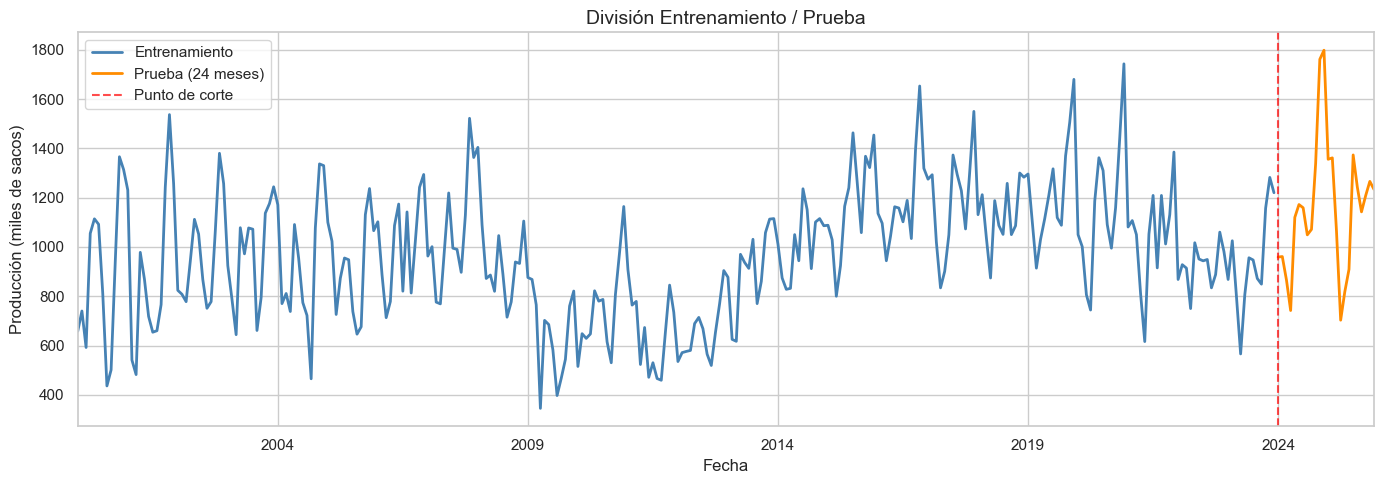

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
train.plot(label="Entrenamiento", ax=ax, color="steelblue")
test.plot(label=f"Prueba ({HORIZONTE} meses)", ax=ax, color="darkorange")
ax.axvline(pd.Timestamp("2024-01-01"), color="red", linestyle="--", alpha=0.7, label="Punto de corte")
ax.set_title("División Entrenamiento / Prueba", fontsize=14)
ax.set_ylabel("Producción (miles de sacos)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Funciones Auxiliares de Evaluación

Definimos funciones reutilizables para calcular métricas y visualizar resultados.

In [10]:
def evaluar_modelo(nombre, pred, real=test):
    """Calcula MAE, RMSE, MAPE y sMAPE para una predicción vs el test real."""
    return {
        "Modelo": nombre,
        "MAE":    round(mae(real,  pred), 2),
        "RMSE":   round(rmse(real, pred), 2),
        "MAPE":   round(mape(real, pred), 3),
        "sMAPE":  round(smape(real, pred), 3),
    }


def graficar_pred(nombre, pred, real=test, train_series=train,
                  intervalo_bajo=None, intervalo_alto=None, color="crimson"):
    """Grafica historia, real y predicción con intervalo de confianza opcional."""
    fig, ax = plt.subplots(figsize=(14, 5))

    # Últimos 48 meses de entrenamiento para contexto visual
    train_series[-48:].plot(label="Histórico (últimos 4 años)", ax=ax, color="steelblue")
    real.plot(label="Real", ax=ax, color="darkorange", linewidth=2)
    pred.plot(label=f"Predicción – {nombre}", ax=ax, color=color, linewidth=2, linestyle="--")

    if intervalo_bajo is not None and intervalo_alto is not None:
        fechas = pred.time_index
        ax.fill_between(
            fechas,
            intervalo_bajo,
            intervalo_alto,
            alpha=0.2, color=color, label="Intervalo 80%"
        )

    ax.set_title(f"Pronóstico: {nombre}", fontsize=14)
    ax.set_ylabel("Producción")
    ax.legend()
    plt.tight_layout()
    plt.show()


# Diccionario acumulativo de resultados
resultados = []
predicciones = {}

print("✓ Funciones auxiliares definidas.")

✓ Funciones auxiliares definidas.


---
## 7. Modelo Baseline – Naive Seasonal

**¿Por qué un baseline?**
Antes de aplicar modelos complejos, necesitamos un punto de referencia simple.
Si un modelo sofisticado no supera al naive, algo está mal.

**Naive Seasonal** simplemente repite el valor del mismo período del año anterior:
$$\hat{y}_{t+h} = y_{t+h-K}$$
donde $K=12$ es el periodo estacional (meses).

Métricas Naive Seasonal:
  Modelo  : Naive Seasonal
  MAE     : 218.08
  RMSE    : 271.29
  MAPE    : 17.822
  sMAPE   : 20.285


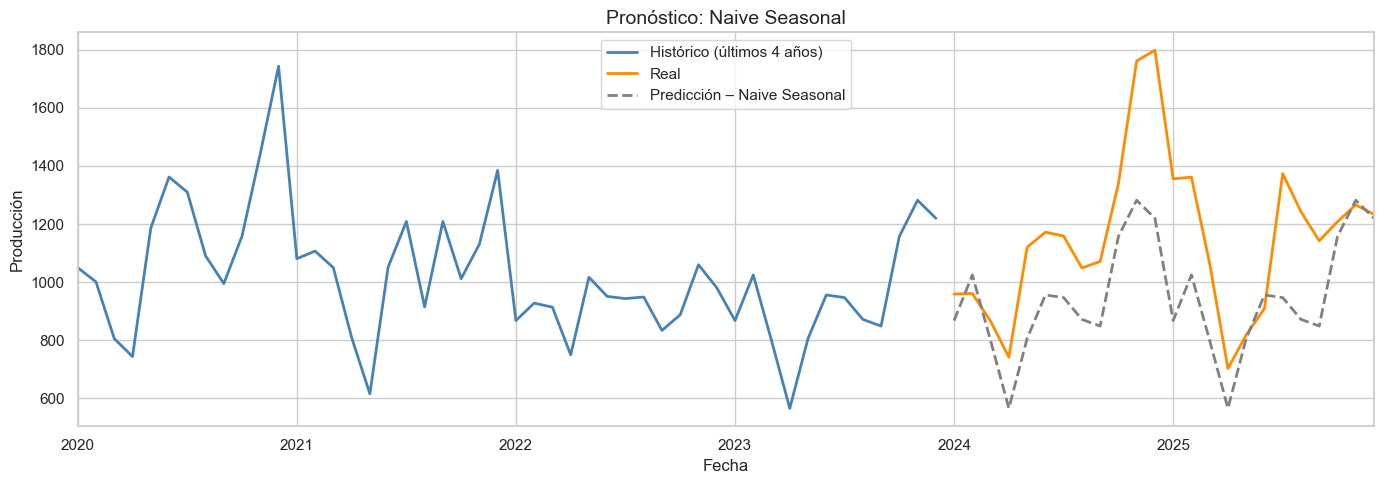

In [11]:
modelo_naive = NaiveSeasonal(K=12)
modelo_naive.fit(train)
pred_naive = modelo_naive.predict(HORIZONTE)

metricas_naive = evaluar_modelo("Naive Seasonal", pred_naive)
resultados.append(metricas_naive)
predicciones["Naive Seasonal"] = pred_naive

print("Métricas Naive Seasonal:")
for k, v in metricas_naive.items():
    print(f"  {k:8}: {v}")

graficar_pred("Naive Seasonal", pred_naive, color="gray")

---
## 8. Suavizamiento Exponencial – Holt-Winters (ETS)

El modelo **ETS (Error, Tendencia, Estacionalidad)** es la generalización del suavizamiento exponencial.

**Holt-Winters** con tres componentes:
- $\alpha$ – suaviza el nivel
- $\beta$ – suaviza la tendencia
- $\gamma$ – suaviza la estacionalidad

**Versión aditiva** (apropiada cuando la amplitud estacional es constante):
$$\hat{y}_{t+h} = L_t + h \cdot B_t + S_{t+h-m}$$

DARTS usa `statsmodels` internamente y optimiza los parámetros automáticamente.

Métricas Holt-Winters:
  Modelo  : Holt-Winters (ETS)
  MAE     : 192.3
  RMSE    : 251.51
  MAPE    : 14.902
  sMAPE   : 16.659


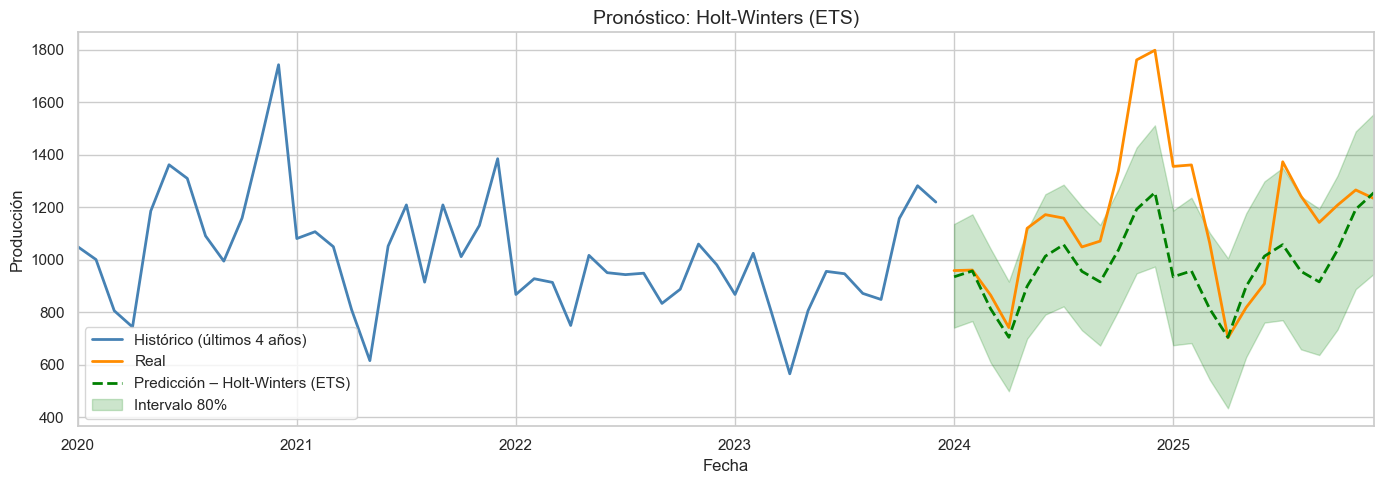

In [12]:
modelo_ets = ExponentialSmoothing(
    seasonal_periods=12,   # estacionalidad anual
    trend=ModelMode.ADDITIVE,        # tendencia aditiva
    seasonal=SeasonalityMode.ADDITIVE,  # estacionalidad aditiva
    damped=True,           # tendencia amortiguada (más conservadora a largo plazo)
    random_state=SEMILLA
)
modelo_ets.fit(train)
pred_ets = modelo_ets.predict(HORIZONTE)

# Intervalos de predicción mediante simulación estocástica
pred_ets_stoch = modelo_ets.predict(
    HORIZONTE,
    num_samples=500  # genera 500 trayectorias posibles
)
p10 = np.quantile(pred_ets_stoch.all_values(), 0.10, axis=-1).flatten()
p90 = np.quantile(pred_ets_stoch.all_values(), 0.90, axis=-1).flatten()

metricas_ets = evaluar_modelo("Holt-Winters (ETS)", pred_ets)
resultados.append(metricas_ets)
predicciones["Holt-Winters (ETS)"] = pred_ets

print("Métricas Holt-Winters:")
for k, v in metricas_ets.items():
    print(f"  {k:8}: {v}")

graficar_pred("Holt-Winters (ETS)", pred_ets,
              intervalo_bajo=p10, intervalo_alto=p90, color="green")

---
## 9. AutoARIMA / SARIMA

**SARIMA** (Seasonal AutoRegressive Integrated Moving Average):
$$\text{SARIMA}(p,d,q)(P,D,Q)_m$$

| Parámetro | Significado |
|-----------|-------------|
| $p, P$ | Orden autoregresivo (no-estacional / estacional) |
| $d, D$ | Grado de diferenciación (para lograr estacionariedad) |
| $q, Q$ | Orden de media móvil |
| $m=12$ | Periodo estacional (mensual → anual) |

**AutoARIMA** busca automáticamente la combinación óptima de parámetros minimizando el criterio AIC.

In [13]:
AutoARIMA()

AutoARIMA(add_encoders=None, quantiles=None, random_state=None)

Ajustando AutoARIMA (puede tomar 1-3 min)...

Modelo seleccionado: AutoARIMA

Metricas AutoARIMA:
  Modelo  : AutoARIMA
  MAE     : 232.51
  RMSE    : 291.4
  MAPE    : 18.29
  sMAPE   : 20.947


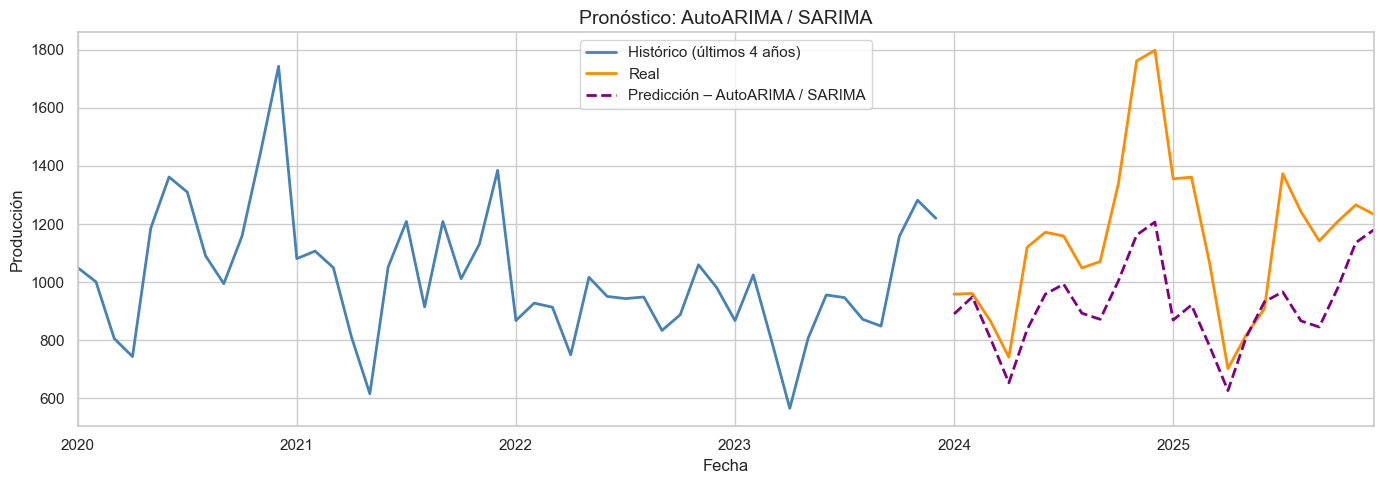

In [14]:
print("Ajustando AutoARIMA (puede tomar 1-3 min)...")



modelo_arima = AutoARIMA(
    seasonal=True,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    d=1,
    D=1,
    stepwise=True,
    season_length=12,  # estacionalidad anual   
    
)
modelo_arima.fit(train)

try:
    print(f"\nModelo seleccionado: {modelo_arima.model}")
except:
    print("\nModelo ajustado correctamente.")

pred_arima = modelo_arima.predict(HORIZONTE)

metricas_arima = evaluar_modelo("AutoARIMA", pred_arima)
resultados.append(metricas_arima)
predicciones["AutoARIMA"] = pred_arima

print("\nMetricas AutoARIMA:")
for k, v in metricas_arima.items():
    print(f"  {k:8}: {v}")

graficar_pred("AutoARIMA / SARIMA", pred_arima, color="purple")

---
## 10. Prophet (Meta / Facebook)

**Prophet** modela la serie como suma de componentes:
$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

- $g(t)$ – función de tendencia (lineal o logística)
- $s(t)$ – estacionalidad (series de Fourier)
- $h(t)$ – efectos de festivos y eventos especiales
- $\varepsilon_t$ – error

**Ventajas:** robusto ante datos faltantes, cambios de tendencia y outliers.
Ideal para datos con fuerte estacionalidad y sin necesidad de tuning manual.

In [15]:
try:
    print("Ajustando Prophet...")
    modelo_prophet = Prophet(
        seasonality_mode="additive",
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        add_seasonalities=None,
        uncertainty_samples=500
    )
    modelo_prophet.fit(train)
    pred_prophet = modelo_prophet.predict(HORIZONTE)

    pred_prophet_stoch = modelo_prophet.predict(HORIZONTE, num_samples=500)
    p10_ph = np.quantile(pred_prophet_stoch.all_values(), 0.10, axis=-1).flatten()
    p90_ph = np.quantile(pred_prophet_stoch.all_values(), 0.90, axis=-1).flatten()

    metricas_prophet = evaluar_modelo("Prophet", pred_prophet)
    resultados.append(metricas_prophet)
    predicciones["Prophet"] = pred_prophet

    print("MÃ©tricas Prophet:")
    for k, v in metricas_prophet.items():
        print(f"  {k:8}: {v}")

    graficar_pred("Prophet", pred_prophet,
                  intervalo_bajo=p10_ph, intervalo_alto=p90_ph, color="tomato")

except Exception as e:
    print(f"Prophet no disponible (omitido): {e}")
    pred_prophet = None

Ajustando Prophet...
Prophet no disponible (omitido): 'Prophet' object has no attribute 'stan_backend'


---
## 11. Modelos de Machine Learning

Los modelos de ML para series de tiempo funcionan como regresores que toman
**ventanas de valores pasados (lags)** como features para predecir valores futuros.

```
Entradas (lags):     [y(t-24), y(t-23), ..., y(t-1), y(t)]
                              ↓
                         Modelo ML
                              ↓
Salidas:             [y(t+1), y(t+2), ..., y(t+H)]
```

**Parámetros clave en DARTS:**
- `lags`: cuántos valores históricos usar como features
- `output_chunk_length`: cuántos pasos predecir en una sola pasada

Entrenando LightGBM...


  File "c:\Users\wsand\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\wsand\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\wsand\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\wsand\anaconda3\Lib\subprocess.

Métricas LightGBM:
  Modelo  : LightGBM
  MAE     : 250.31
  RMSE    : 314.09
  MAPE    : 19.721
  sMAPE   : 22.881


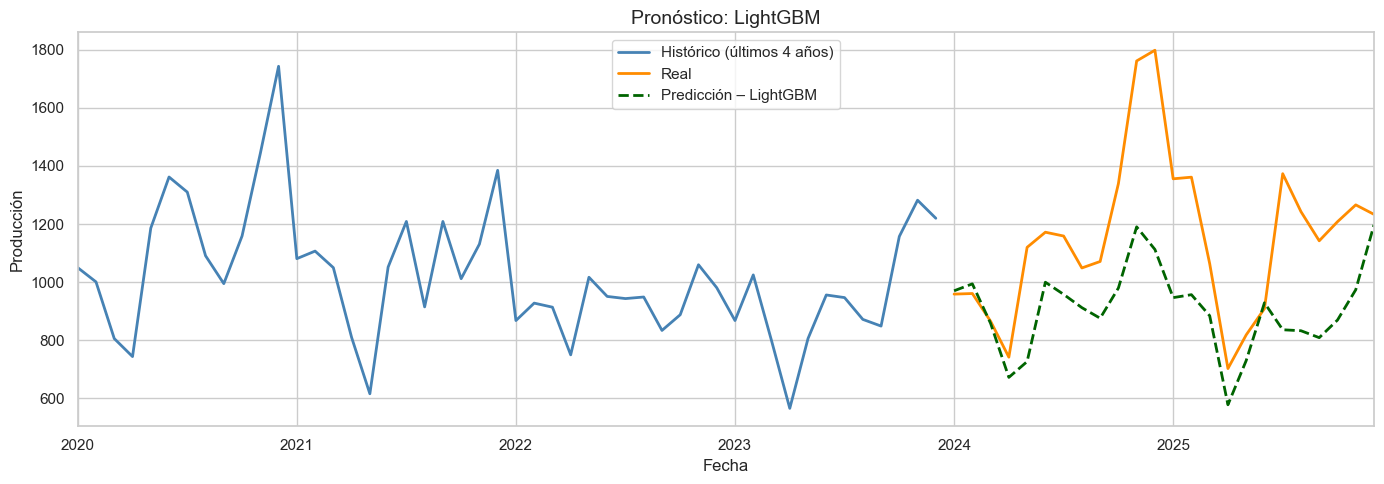

In [16]:
# ── LightGBM ────────────────────────────────────────────────────────────────
# Gradient boosting optimizado para velocidad y bajo consumo de memoria
print("Entrenando LightGBM...")

modelo_lgbm = LightGBMModel(
    lags=36,                    # usa los últimos 36 meses como features
    output_chunk_length=HORIZONTE,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=5,
    random_state=SEMILLA,
    verbose=-1
)
modelo_lgbm.fit(train)
pred_lgbm = modelo_lgbm.predict(HORIZONTE)

metricas_lgbm = evaluar_modelo("LightGBM", pred_lgbm)
resultados.append(metricas_lgbm)
predicciones["LightGBM"] = pred_lgbm

print("Métricas LightGBM:")
for k, v in metricas_lgbm.items():
    print(f"  {k:8}: {v}")

graficar_pred("LightGBM", pred_lgbm, color="darkgreen")

Entrenando Random Forest...
Métricas Random Forest:
  Modelo  : Random Forest
  MAE     : 254.85
  RMSE    : 314.61
  MAPE    : 20.193
  sMAPE   : 22.74


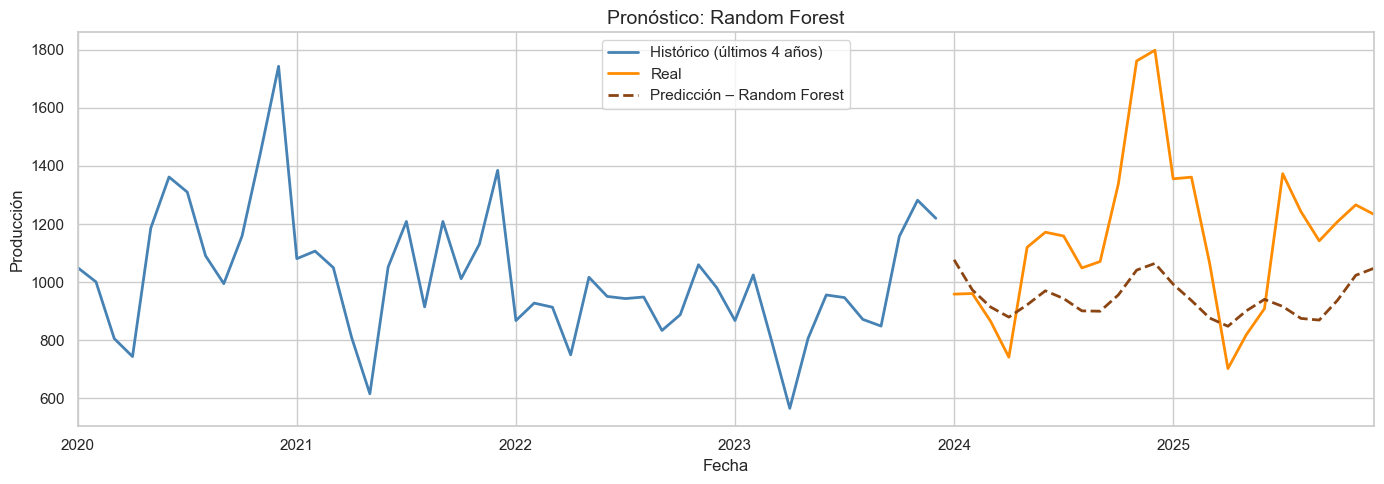

In [17]:
# ── Random Forest ───────────────────────────────────────────────────────────
# Ensemble de árboles de decisión, robusto ante outliers y no requiere
# que los datos sean estacionarios
print("Entrenando Random Forest...")

modelo_rf = RandomForest(
    lags=36,
    output_chunk_length=HORIZONTE,
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=SEMILLA,
    n_jobs=-1   # usar todos los núcleos disponibles
)
modelo_rf.fit(train)
pred_rf = modelo_rf.predict(HORIZONTE)

metricas_rf = evaluar_modelo("Random Forest", pred_rf)
resultados.append(metricas_rf)
predicciones["Random Forest"] = pred_rf

print("Métricas Random Forest:")
for k, v in metricas_rf.items():
    print(f"  {k:8}: {v}")

graficar_pred("Random Forest", pred_rf, color="saddlebrown")

---
## 12. Chronos-2 (Foundation Model – Amazon)

**Chronos** es un modelo de lenguaje adaptado para series de tiempo.
Fue pre-entrenado en millones de series de distintos dominios y puede hacer
predicciones **sin entrenamiento adicional** (zero-shot).

**Funcionamiento:**
1. Tokeniza la serie de tiempo como si fuera texto
2. Usa un transformador (T5) para generar distribuciones futuras
3. Produce predicciones probabilísticas

> **Ventaja:** no necesita datos de entrenamiento del dominio específico.  
> **Desventaja:** más lento y requiere GPU para grandes volúmenes.

In [18]:
# Intentamos primero con la integraciÃ³n nativa de DARTS (ChronosBoltModel)

chronos_disponible = False

try:
    from darts.models import ChronosBoltModel
    print("Usando ChronosBoltModel de DARTS...")

    modelo_chronos_darts = ChronosBoltModel(
        model_path="amazon/chronos-bolt-base",
        device_map="cpu"
    )
    pred_chronos = modelo_chronos_darts.predict(n=HORIZONTE, series=train)
    chronos_disponible = True
    print("âœ“ Chronos (DARTS) ajustado correctamente.")

except Exception as e:
    print(f"ChronosBoltModel no disponible: {e}")
    print("Usando chronos-forecasting directamente...")
    chronos_disponible = None  # seÃ±al de fallback

ChronosBoltModel no disponible: cannot import name 'ChronosBoltModel' from 'darts.models' (c:\Users\wsand\anaconda3\Lib\site-packages\darts\models\__init__.py)
Usando chronos-forecasting directamente...


In [19]:
# Fallback: chronos-forecasting directamente

if chronos_disponible is None:
    from chronos import Chronos2Pipeline

    pipeline_ch = Chronos2Pipeline.from_pretrained(
        "amazon/chronos-2",
        device_map="cpu"
    )

    contexto = torch.tensor(
        train.values().flatten(),
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)  # shape: [1, 1, T]

    forecast_tensor = pipeline_ch.predict(
        inputs=contexto,
        prediction_length=HORIZONTE,
    )

    # â”€â”€ DiagnÃ³stico: ver forma real del output â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    print(f"tipo forecast_tensor : {type(forecast_tensor)}")
    if isinstance(forecast_tensor, list):
        print(f"  len={len(forecast_tensor)}")
        elem = forecast_tensor[0]
        print(f"  forecast_tensor[0] tipo={type(elem)}, shape={getattr(elem,'shape', len(elem) if hasattr(elem,'__len__') else 'escalar')}")
    elif hasattr(forecast_tensor, 'shape'):
        print(f"  shape={forecast_tensor.shape}")

    # â”€â”€ ExtracciÃ³n robusta: convierte cualquier formato a 1D numpy (H,) â”€â”€â”€â”€â”€
    if isinstance(forecast_tensor, list):
        raw = forecast_tensor[0]
    else:
        raw = forecast_tensor

    # torch tensor -> numpy
    if hasattr(raw, 'detach'):
        raw = raw.detach().numpy()
    else:
        raw = np.asarray(raw)

    mediana = raw.flatten()
    print(f"mediana shape={mediana.shape}, HORIZONTE={HORIZONTE}")

    # Si el modelo devuelve mÃºltiples variantes (ej. cuantiles), tomar la primera
    if len(mediana) != HORIZONTE:
        raw2d = raw.reshape(-1, HORIZONTE) if raw.size % HORIZONTE == 0 else None
        if raw2d is not None:
            mediana = raw2d[0]
            print(f"  -> reshape a ({raw2d.shape}), usando fila 0: shape={mediana.shape}")
        else:
            raise ValueError(f"No se puede extraer HORIZONTE={HORIZONTE} pasos del output shape={raw.shape}")

    cuantil_10 = mediana
    cuantil_90 = mediana

    fechas_futuras = pd.date_range(
        start=train.end_time() + pd.DateOffset(months=1),
        periods=HORIZONTE,
        freq="MS"
    )

    pred_chronos = TimeSeries.from_times_and_values(
        times=fechas_futuras,
        values=mediana
    )
    print("âœ“ Chronos-2 ajustado correctamente.")
    chronos_disponible = True

else:
    # ChronosBoltModel exitoso: prediccion determinista
    cuantil_10 = pred_chronos.values().flatten()
    cuantil_90 = pred_chronos.values().flatten()

tipo forecast_tensor : <class 'list'>
  len=1
  forecast_tensor[0] tipo=<class 'torch.Tensor'>, shape=torch.Size([1, 21, 24])
mediana shape=(504,), HORIZONTE=24
  -> reshape a ((21, 24)), usando fila 0: shape=(24,)
âœ“ Chronos-2 ajustado correctamente.


Métricas Chronos-2:
  Modelo  : Chronos-2
  MAE     : 716.12
  RMSE    : 755.51
  MAPE    : 61.043
  sMAPE   : 89.648


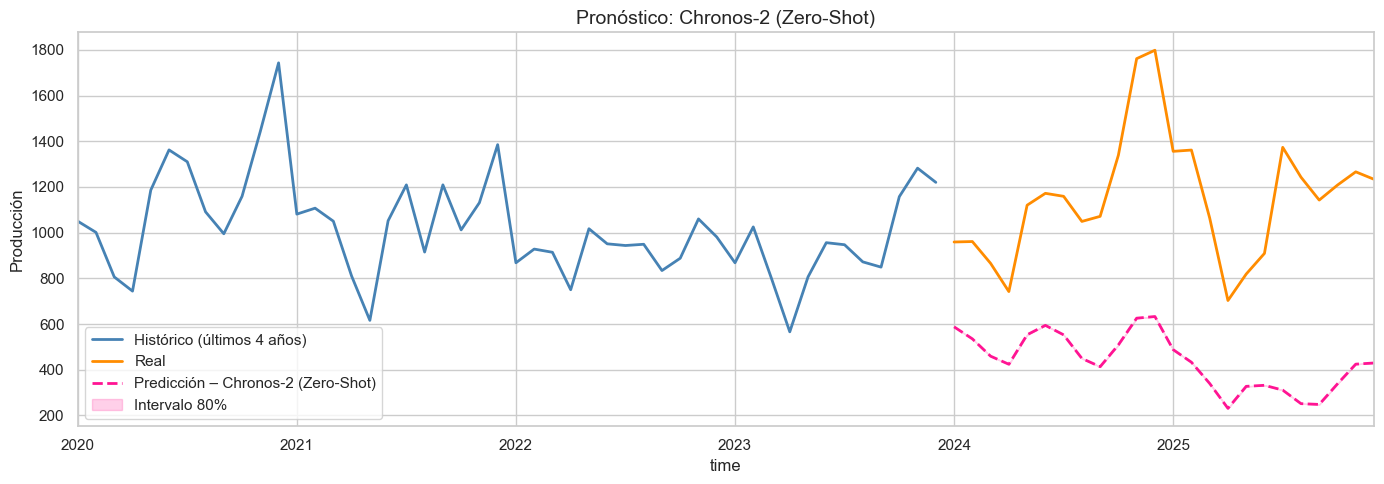

In [20]:
if chronos_disponible:
    metricas_chronos = evaluar_modelo("Chronos-2", pred_chronos)
    resultados.append(metricas_chronos)
    predicciones["Chronos-2"] = pred_chronos

    print("Métricas Chronos-2:")
    for k, v in metricas_chronos.items():
        print(f"  {k:8}: {v}")

    graficar_pred("Chronos-2 (Zero-Shot)", pred_chronos,
                  intervalo_bajo=cuantil_10, intervalo_alto=cuantil_90,
                  color="deeppink")

---
## 13. Comparación de Modelos y Métricas

### Guía rápida de interpretación:

| Métrica | Fórmula | Mejor valor | Sensible a outliers |
|---------|---------|------------|---------------------|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Mínimo | No |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Mínimo | Sí |
| **MAPE** | $\frac{100}{n}\sum\left|\frac{y_i - \hat{y}_i}{y_i}\right|$ | Mínimo (%) | Moderado |
| **sMAPE** | $\frac{200}{n}\sum\frac{|y_i - \hat{y}_i|}{|y_i| + |\hat{y}_i|}$ | Mínimo (%) | Bajo |

> **Regla práctica:** el mejor modelo es el que tiene menor MAPE y RMSE simultáneamente.

In [21]:
# ── Tabla comparativa ───────────────────────────────────────────────────────
df_metricas = pd.DataFrame(resultados).set_index("Modelo")

# Resaltar el mejor en cada columna
def resaltar_minimo(s):
    return ["background-color: #d4f0d4; font-weight: bold"
            if v == s.min() else "" for v in s]

display(
    df_metricas.style
    .apply(resaltar_minimo, axis=0)
    .format("{:.3f}")
    .set_caption("Comparación de modelos – verde = mejor en cada métrica")
)

,MAE,RMSE,MAPE,sMAPE
Modelo,,,,
Naive Seasonal,218.080,271.290,17.822,20.285
Holt-Winters (ETS),192.300,251.510,14.902,16.659
AutoARIMA,232.510,291.400,18.290,20.947
LightGBM,250.310,314.090,19.721,22.881
Random Forest,254.850,314.610,20.193,22.740
Chronos-2,716.120,755.510,61.043,89.648


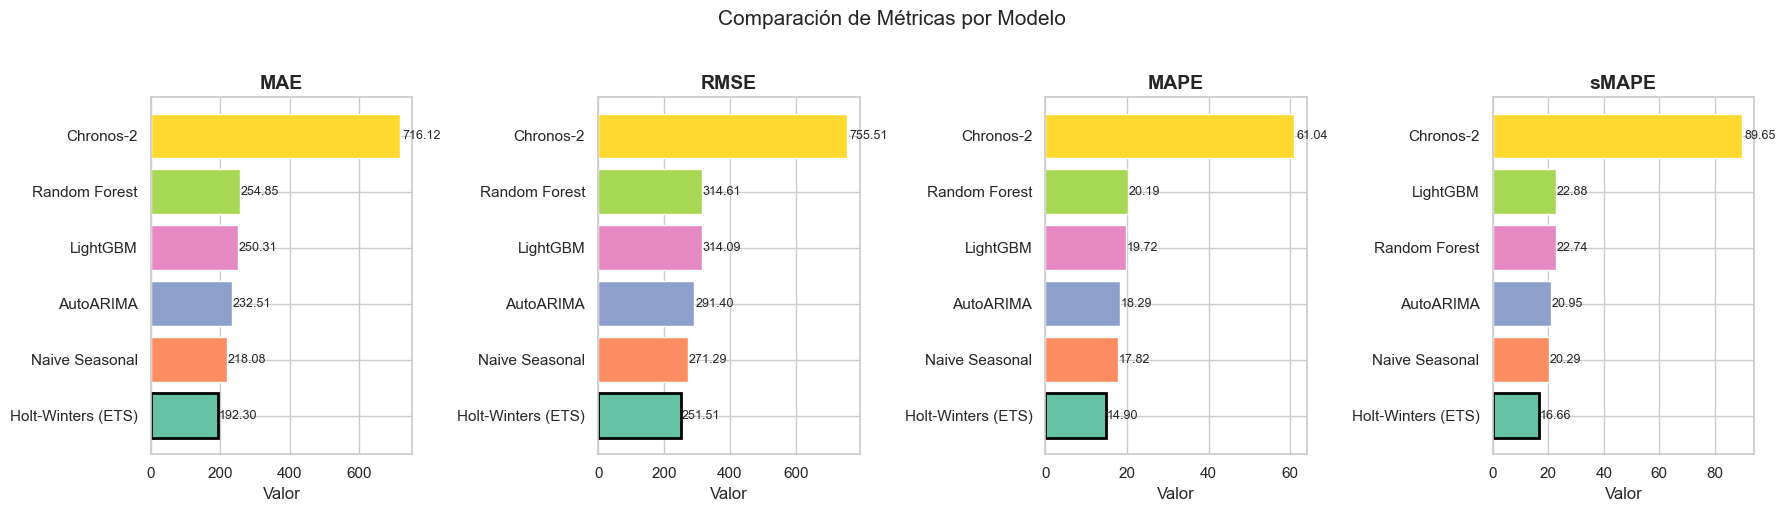

In [22]:
# ── Gráfico de barras: comparación por métrica ─────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metricas_lista = ["MAE", "RMSE", "MAPE", "sMAPE"]
colores = sns.color_palette("Set2", n_colors=len(df_metricas))

for ax, metrica in zip(axes, metricas_lista):
    vals = df_metricas[metrica].sort_values()
    bars = ax.barh(vals.index, vals.values, color=colores[:len(vals)])
    ax.set_title(metrica, fontweight="bold")
    ax.set_xlabel("Valor")
    # Anotar valores en las barras
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=9)
    # Resaltar el mejor
    bars[0].set_edgecolor("black")
    bars[0].set_linewidth(2)

plt.suptitle("Comparación de Métricas por Modelo", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

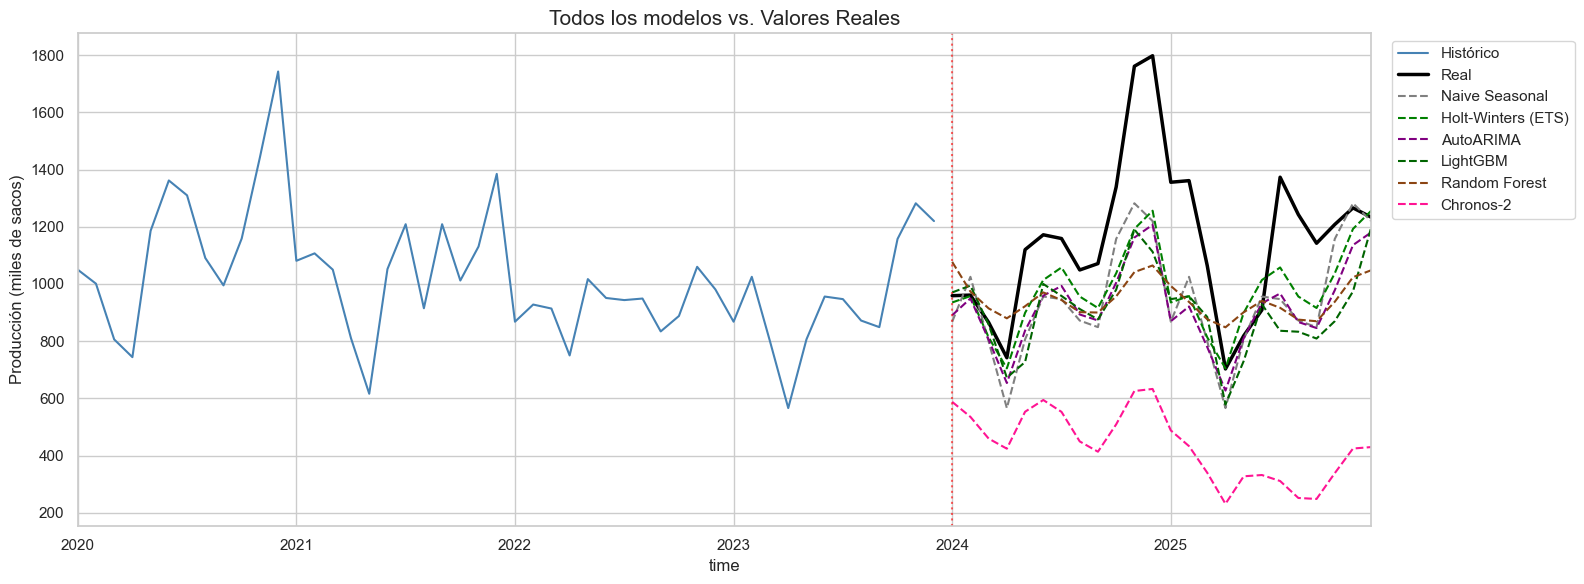

In [23]:
# ── Gráfico superpuesto: todos los modelos vs real ──────────────────────────
colores_modelos = {
    "Naive Seasonal":    "gray",
    "Holt-Winters (ETS)": "green",
    "AutoARIMA":         "purple",
    "Prophet":           "tomato",
    "LightGBM":         "darkgreen",
    "Random Forest":    "saddlebrown",
    "Chronos-2":        "deeppink",
}

fig, ax = plt.subplots(figsize=(16, 6))

# Histórico (últimos 4 años)
train[-48:].plot(ax=ax, label="Histórico", color="steelblue", linewidth=1.5)

# Real
test.plot(ax=ax, label="Real", color="black", linewidth=2.5, linestyle="-")

# Predicciones
for nombre, pred in predicciones.items():
    color = colores_modelos.get(nombre, "orange")
    pred.plot(ax=ax, label=nombre, color=color, linewidth=1.5, linestyle="--")

ax.axvline(pd.Timestamp("2024-01-01"), color="red", linestyle=":", alpha=0.6)
ax.set_title("Todos los modelos vs. Valores Reales", fontsize=15)
ax.set_ylabel("Producción (miles de sacos)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

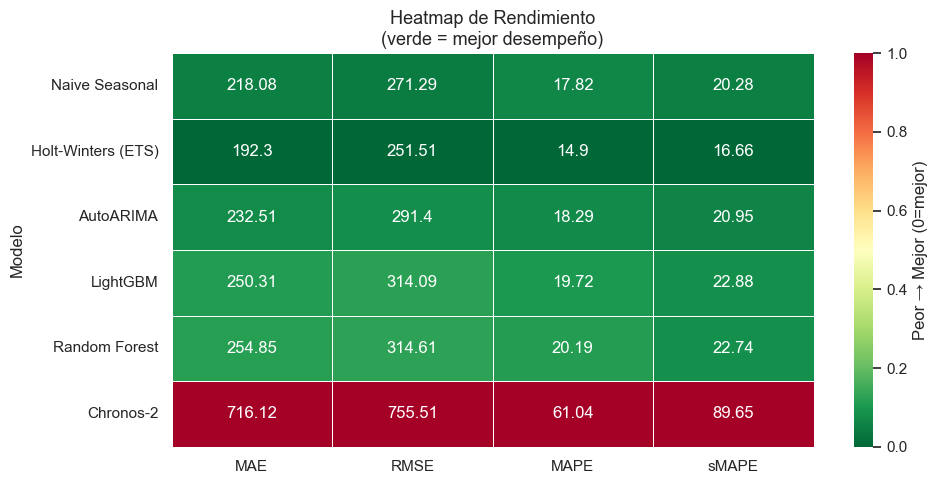

In [24]:
# ── Heatmap de métricas normalizadas ───────────────────────────────────────
# Normalizar 0-1 para cada métrica (0 = mejor, 1 = peor)
df_norm = df_metricas.copy()
for col in df_norm.columns:
    mn, mx = df_norm[col].min(), df_norm[col].max()
    df_norm[col] = (df_norm[col] - mn) / (mx - mn + 1e-9)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    df_norm,
    annot=df_metricas.round(2),
    fmt="g",
    cmap="RdYlGn_r",  # verde=bueno, rojo=malo
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Peor → Mejor (0=mejor)"}
)
ax.set_title("Heatmap de Rendimiento\n(verde = mejor desempeño)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 14. Mejor Modelo – Análisis de Residuos

Una vez identificado el mejor modelo, analizamos sus residuos para verificar que:
1. **No tienen autocorrelación** (el modelo capturó toda la estructura)
2. **Se distribuyen normalmente** (supuesto de muchos modelos estadísticos)
3. **Tienen varianza constante** (homocedasticidad)

Mejor modelo por MAPE: Holt-Winters (ETS)
MAE      192.300
RMSE     251.510
MAPE      14.902
sMAPE     16.659
Name: Holt-Winters (ETS), dtype: float64


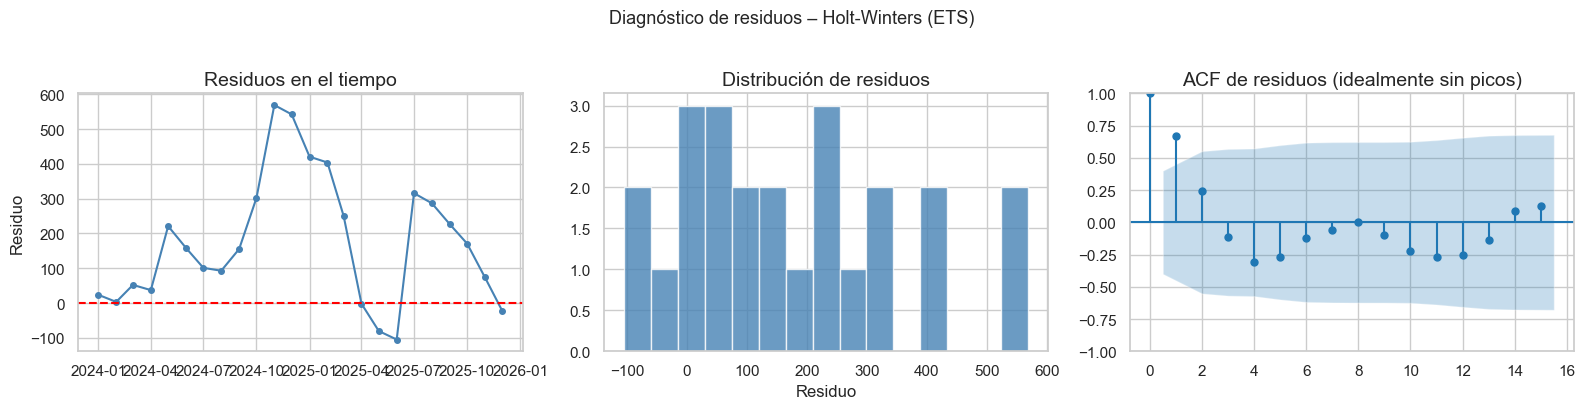

In [25]:
# Identificar el modelo con menor MAPE
mejor_modelo_nombre = df_metricas["MAPE"].idxmin()
mejor_pred = predicciones[mejor_modelo_nombre]

print(f"Mejor modelo por MAPE: {mejor_modelo_nombre}")
print(df_metricas.loc[mejor_modelo_nombre])

# Calcular residuos
residuos = (test - mejor_pred).values().flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Residuos en el tiempo
axes[0].plot(test.time_index, residuos, color="steelblue", marker="o", markersize=4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuos en el tiempo")
axes[0].set_ylabel("Residuo")

# 2. Histograma
axes[1].hist(residuos, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].set_title("Distribución de residuos")
axes[1].set_xlabel("Residuo")

# 3. ACF de residuos (no debe tener picos significativos)
plot_acf(residuos, lags=min(15, len(residuos)-2), ax=axes[2],
         title="ACF de residuos (idealmente sin picos)")

plt.suptitle(f"Diagnóstico de residuos – {mejor_modelo_nombre}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 15. Pronóstico Futuro con el Mejor Modelo

Reentrenamos el mejor modelo con **toda la serie** (train + test)
y generamos el pronóstico para los próximos 12 meses.

Reentrenando 'Holt-Winters (ETS)' con la serie completa...


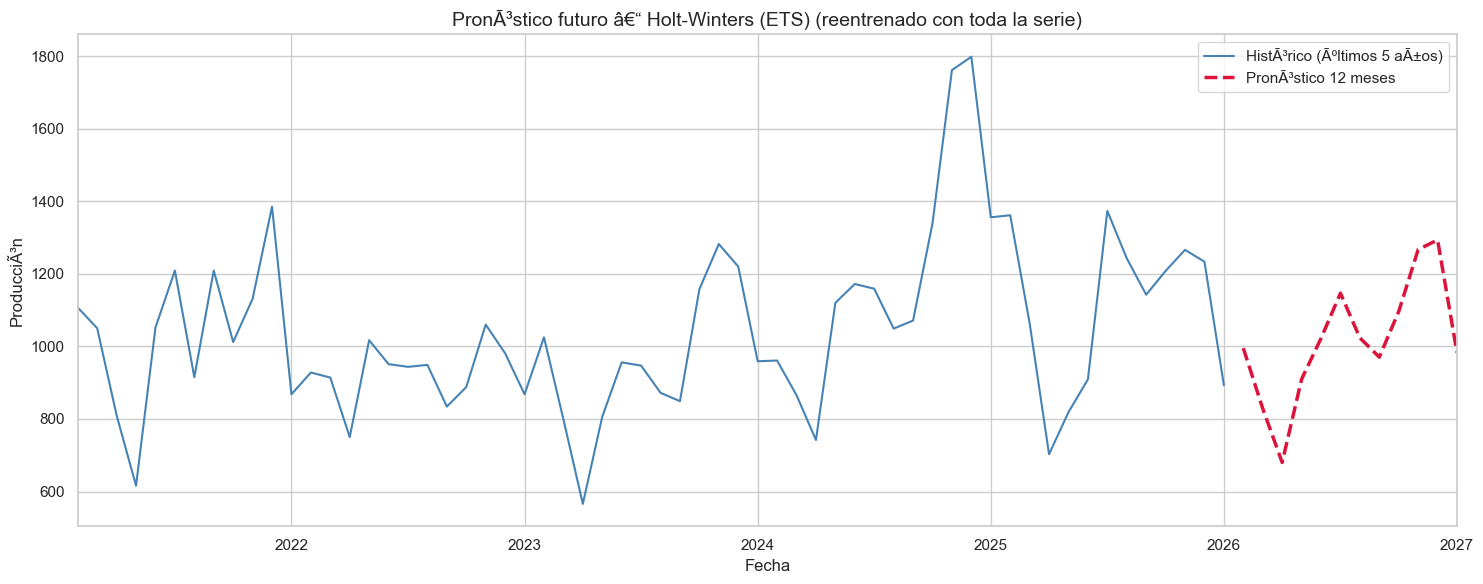


Valores pronosticados:


'     Fecha  Produccion_Pronosticada\n2026-02-01                    995.1\n2026-03-01                    828.5\n2026-04-01                    680.1\n2026-05-01                    909.4\n2026-06-01                   1022.1\n2026-07-01                   1146.5\n2026-08-01                   1023.5\n2026-09-01                    970.3\n2026-10-01                   1096.1\n2026-11-01                   1266.8\n2026-12-01                   1293.3\n2027-01-01                    982.8'

In [26]:
HORIZONTE_FUTURO = 12  # 1 aÃ±o hacia el futuro

print(f"Reentrenando '{mejor_modelo_nombre}' con la serie completa...")

modelos_config = {
    "Naive Seasonal":    lambda: NaiveSeasonal(K=12),
    "Holt-Winters (ETS)": lambda: ExponentialSmoothing(
        seasonal_periods=12, trend=ModelMode.ADDITIVE, seasonal=SeasonalityMode.ADDITIVE,
        damped=True, random_state=SEMILLA),
    "AutoARIMA":         lambda: AutoARIMA(seasonal=True, stepwise=True,
                                           suppress_warnings=True),
    "LightGBM":          lambda: LightGBMModel(lags=36,
                                               output_chunk_length=HORIZONTE_FUTURO,
                                               n_estimators=300, random_state=SEMILLA,
                                               verbose=-1),
    "Random Forest":     lambda: RandomForest(lags=36,
                                              output_chunk_length=HORIZONTE_FUTURO,
                                              n_estimators=300, random_state=SEMILLA),
}

if mejor_modelo_nombre in modelos_config:
    modelo_final = modelos_config[mejor_modelo_nombre]()
    modelo_final.fit(serie)  # serie completa
    pronostico_futuro = modelo_final.predict(HORIZONTE_FUTURO)

    fig, ax = plt.subplots(figsize=(15, 6))
    serie[-60:].plot(ax=ax, label="HistÃ³rico (Ãºltimos 5 aÃ±os)", color="steelblue", linewidth=1.5)
    pronostico_futuro.plot(ax=ax, label=f"PronÃ³stico {HORIZONTE_FUTURO} meses",
                           color="crimson", linewidth=2.5, linestyle="--")
    ax.set_title(f"PronÃ³stico futuro â€“ {mejor_modelo_nombre} (reentrenado con toda la serie)",
                 fontsize=14)
    ax.set_ylabel("ProducciÃ³n")
    ax.legend()
    plt.tight_layout()
    plt.show()

    df_futuro = pd.DataFrame({
        "Fecha": pronostico_futuro.time_index,
        "Produccion_Pronosticada": pronostico_futuro.values().flatten().round(1)
    })
    print("\nValores pronosticados:")
    display(df_futuro.to_string(index=False))
else:
    print(f"Reentrenamiento no configurado para '{mejor_modelo_nombre}'.")

---
## 16. Conclusiones y Recomendaciones

### Resumen del análisis

| Familia | Modelo | Cuándo es mejor |
|---------|--------|-----------------|
| **Baseline** | Naive Seasonal | Punto de referencia mínimo |
| **Estadístico** | Holt-Winters | Series con tendencia y estacionalidad estable |
| **Estadístico** | SARIMA | Series estacionarias con lags claros en ACF/PACF |
| **Aditivo** | Prophet | Datos con múltiples estacionalidades y festivos |
| **ML** | LightGBM | Muchos datos, relaciones no lineales complejas |
| **ML** | Random Forest | Robustez ante outliers, interpretabilidad |
| **Foundation** | Chronos-2 | Zero-shot, sin datos de entrenamiento disponibles |

### Próximos pasos

1. **Variables externas (covariables):** temperatura, precio internacional del café, 
   exportaciones → mejorar modelos ML con `future_covariates`
2. **Backtesting robusto:** evaluar sobre múltiples ventanas con `darts.backtesting`
3. **Ensemble:** combinar predicciones de varios modelos
4. **Modelos profundos:** N-BEATS, TFT, NHiTS disponibles en DARTS

```python
# Ejemplo de backtesting en DARTS
from darts.models import ExponentialSmoothing
from darts.utils.historical_forecasts import historical_forecasts

modelo = ExponentialSmoothing(seasonal_periods=12)
backtest = serie.backtest(
    model=modelo,
    start=0.75,        # usar 75% como entrenamiento inicial
    forecast_horizon=12,
    metric=mape
)
```

---
*Notebook creado con DARTS · Producción de café de Colombia · 2000–2026*